In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/00010
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 7
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4500000000000001 0.40000000000000013
-------  14 0.4250000000000001 0.4500000000000002
-------  21 0.47500000000000014 0.4750000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  42 0.4250000000000001 0.5750000000000003
-------  49 0.4500000000000001 0.6000000000000003
-------  56 0.4500000000000001 0.6250000000000003
-------  63 0.4500000000000001 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  84 0.4500000000000001 0.7250000000000004
-------  91 0.4250000000000001 0.7500000000000004
-------  98 0.6000000000000003 0.7500000000000004
-------  105 0.5750000000000002 0.7750000000000005
-------  112 0.5500000000000003 0.8000000000000005
-------  119 0.5250000000000001 0.8250000000000005
-------  126 0.5000000000000002 0.8500000000000005
-------  133 0.47500000000000014 0.87500000000

In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  0 , total integrated cost =  13557.205108931135
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  14 0.4250000000000001 0.4500000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8796.175560697715
Gradient descend method:  None
RUN  0 , total integrated cost =  8796.175560697715
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  21 0.47500000000000014 0.47500000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  1217.1004646667843
RUN  2 , total integrated cost =  145.54265181675115
RUN  3 , total integrated cost =  81.18076627177815
RUN  4 , total integrated cost =  57.89040775735947
RUN  5 , total integrated cost =  47.246167878868285
RUN  6 , total integrated cost =  37.964471287131595
RUN  7 , total integrated cost =  30.77362490051481
RUN  8 , total integrated cost =  21.662904899750878
RUN  9 , total integrated cost =  20.603745953979608
RUN  10 , total integrated cost =  19.57246499260319
RUN  11 , total integrated cost =  18.513259872184918
RUN  12 , total integrated cost =  17.412786267335374
RUN  13 , total integrated cost =  16.53979995815088
RUN  14 , total integrated cost =  15.48569270260398
RUN  15 , total integrated cost =  15.065837929236764
RUN 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  47 , total integrated cost =  13.364006991165937
Improved over  47  iterations in  11.94173033349216  seconds by  99.77358375709682  percent.
Problem in initial value trasfer:  Vmean_exc -56.627620609847234 -56.62762055099662
weight =  4416.644261814645
set cost params:  1.0 0.0 4416.644261814645
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5873.038102885881
Gradient descend method:  None
RUN  1 , total integrated cost =  5069.690736000906
RUN  2 , total integrated cost =  5068.007241587993
RUN  3 , total integrated cost =  5066.974565799634
RUN  4 , total integrated cost =  5026.069066718552
RUN  5 , total integrated cost =  5024.404141392098
RUN  6 , total integrated cost =  5024.3685680614835
RUN  7 , total integrated cost =  5024.361606003612
RUN  8 , total integrated cost =  5024.359586832437
RUN  9 , total integrated cost =  5024.358710810786
RUN  10 , total integrated cost =  5024.358348125489
RUN  11 , total integ

ERROR:root:Problem in initial value trasfer


RUN  19 , total integrated cost =  5024.357915449812
RUN  20 , total integrated cost =  5024.357915448925
Control only changes marginally.
RUN  22 , total integrated cost =  5024.3579154489125
Improved over  22  iterations in  0.5075158700346947  seconds by  14.45044579261193  percent.
Problem in initial value trasfer:  Vmean_exc -56.62596343265864 -56.62596386841035
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  1 , total integrated cost =  346.9960943978102
RUN  2 , total integrated cost =  47.83572234544711
RUN  3 , total integrated cost =  27.075384594359758
RUN  4 , total integrated cost =  19.88089160376465
RUN  5 , total integrated cost =  18.2781418167667
RUN  6 , total integrated cost =  18.25208884040906
RUN  7 , total integrated cost =  17.909308303204437
RUN  8 , total integrated cost =  17.7831473362482
RUN  9 , to

...

RUN  11 , total integrated cost =  36290.28730042994
Control only changes marginally.
RUN  11 , total integrated cost =  36290.28730042994
Improved over  11  iterations in  0.31260497868061066  seconds by  6.560427908204659  percent.
Problem in initial value trasfer:  Vmean_exc -56.699770630759026 -56.699770511548685
-------  105 0.5750000000000002 0.7750000000000005
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33891.050588370264
Gradient descend method:  None
RUN  1 , total integrated cost =  4972.206342285528
RUN  2 , total integrated cost =  350.53076722998736
RUN  3 , total integrated cost =  340.94679618713417


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  336.4116488146267
RUN  5 , total integrated cost =  333.0693701850853
RUN  6 , total integrated cost =  330.68729146790673
RUN  7 , total integrated cost =  330.68729146790673
Control only changes marginally.
RUN  7 , total integrated cost =  330.68729146790673
Improved over  7  iterations in  0.3614682015031576  seconds by  99.02426367513853  percent.
Problem in initial value trasfer:  Vmean_exc -56.703033912163264 -56.70305212325804
weight =  1024.86704094159
set cost params:  1.0 0.0 1024.86704094159
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28053.678672441936
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  28053.678672441936
Control only changes marginally.
RUN  1 , total integrated cost =  28053.678672441936
Improved over  1  iterations in  0.09867902286350727  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.703033912163264 -56.70305212325804
-------  112 0.5500000000000003 0.8000000000000005
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28715.541829737766
Gradient descend method:  None
RUN  1 , total integrated cost =  28715.541829737766
Control only changes marginally.
RUN  1 , total integrated cost =  28715.541829737766
Improved over  1  iterations in  0.0605450514703989  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28715.541829737766
Gradient descend method:  None
RUN  1 , total integrated cost =  28715.541829737766
Control only changes marginally.
RUN  1 , total integr

/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


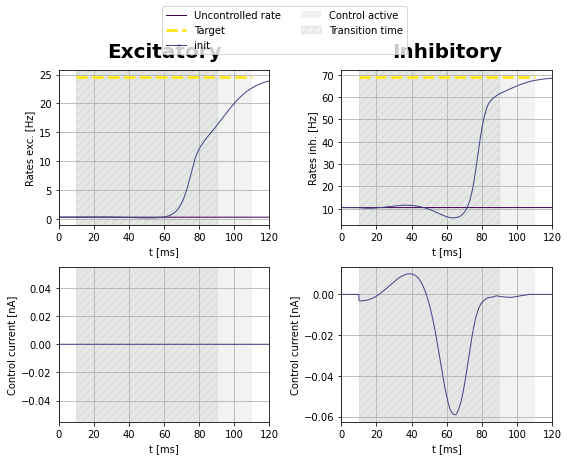

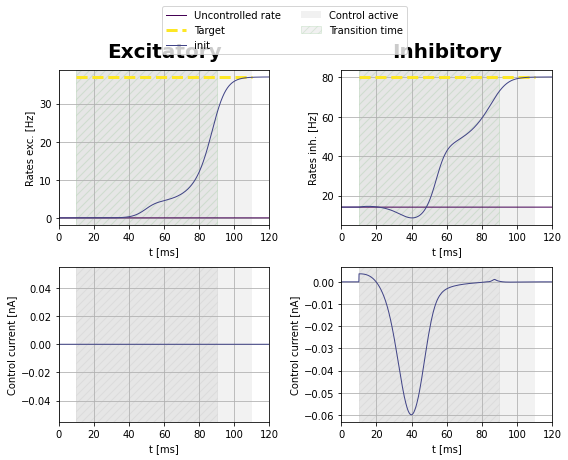

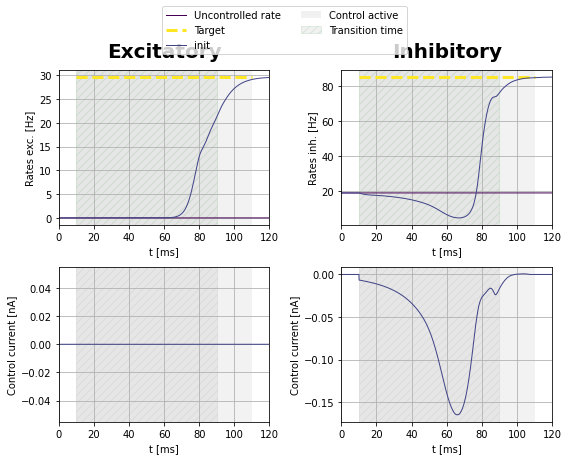

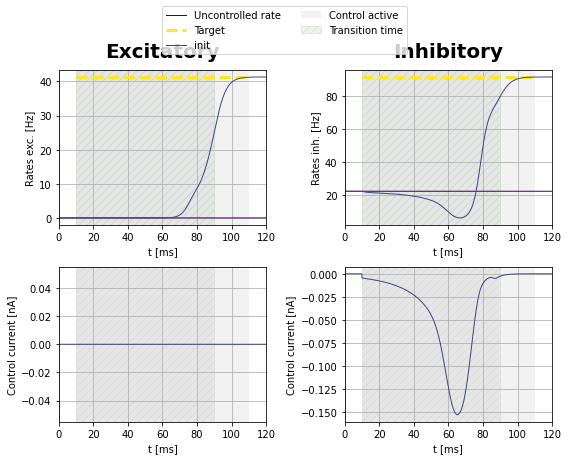

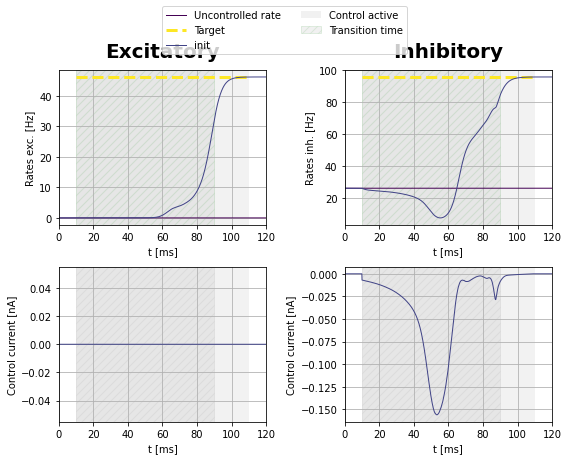

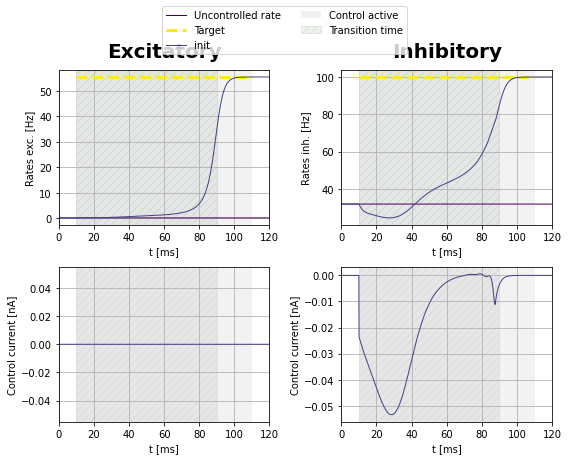

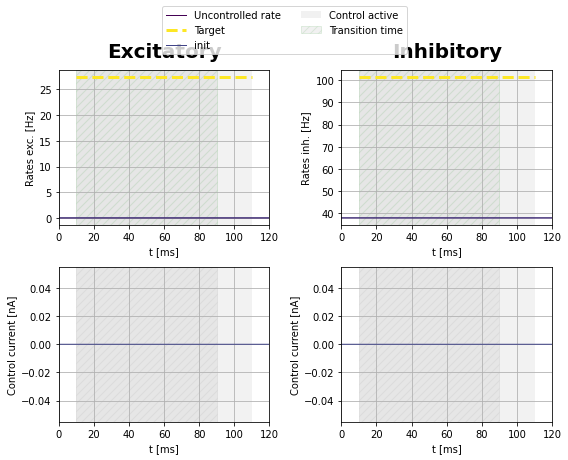

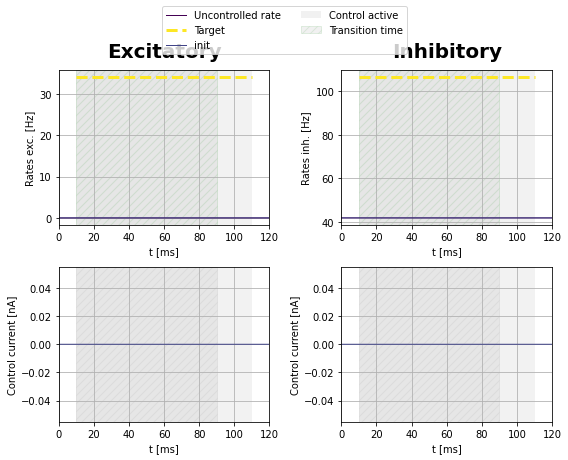

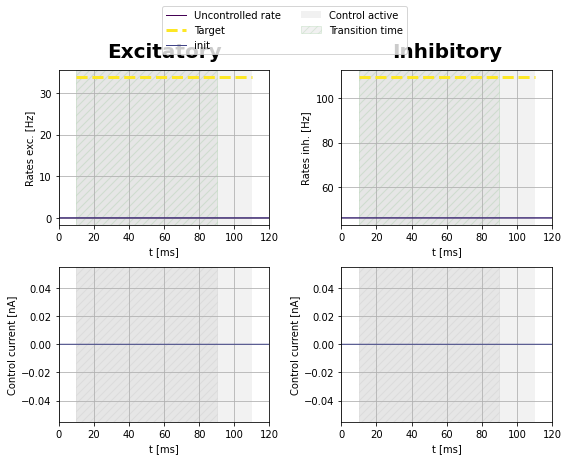

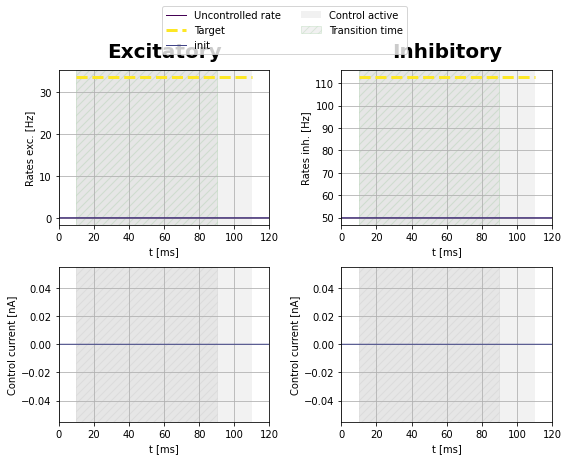

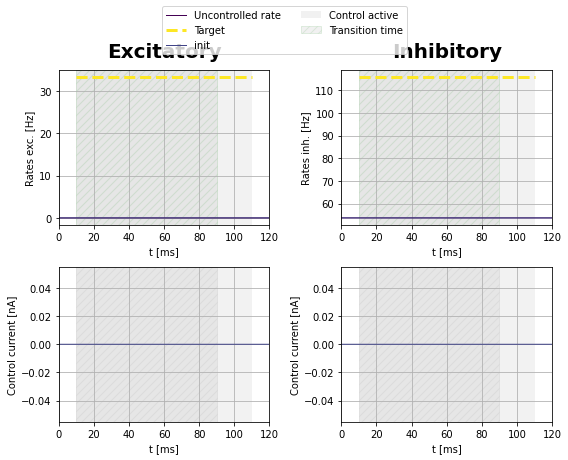

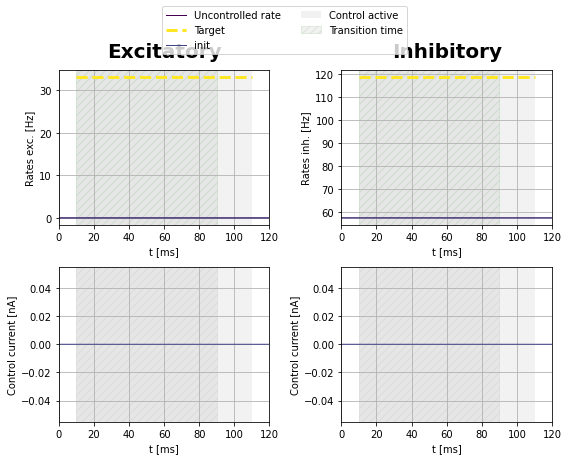

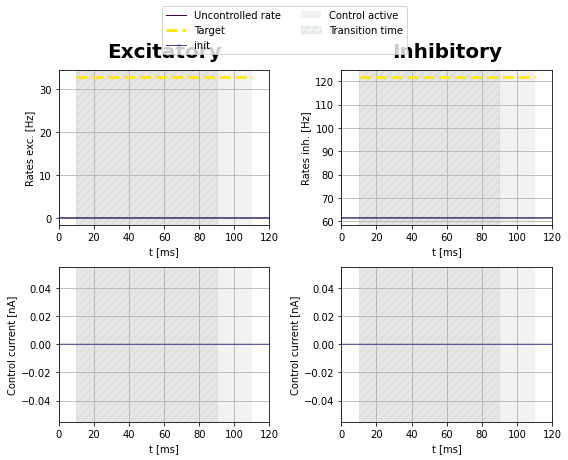

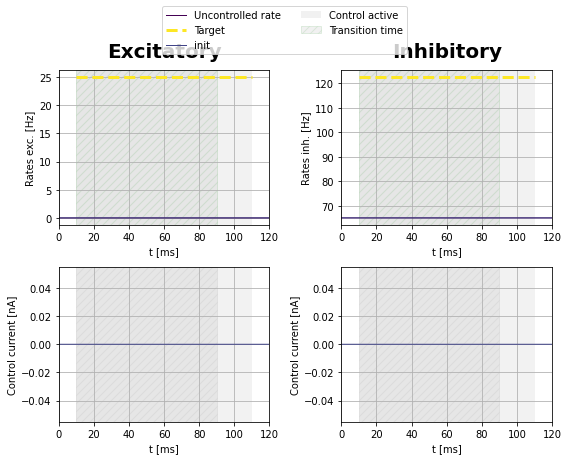

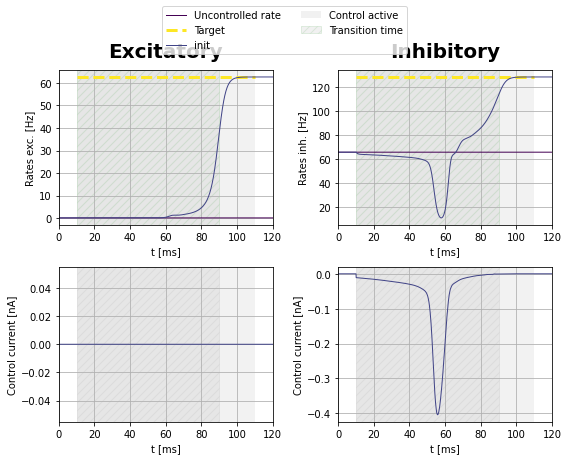

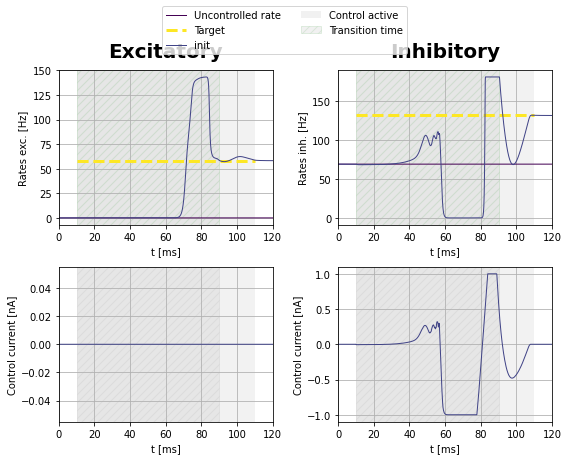

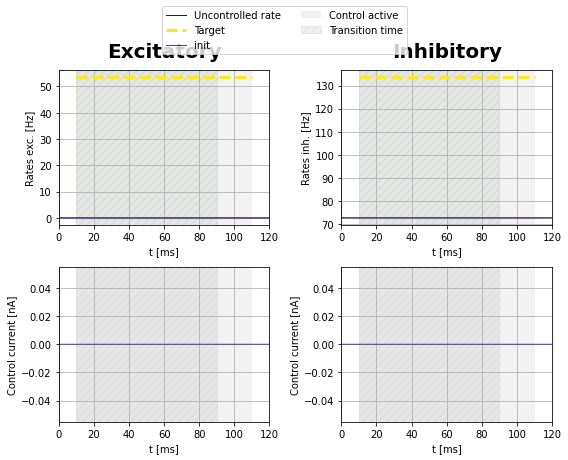

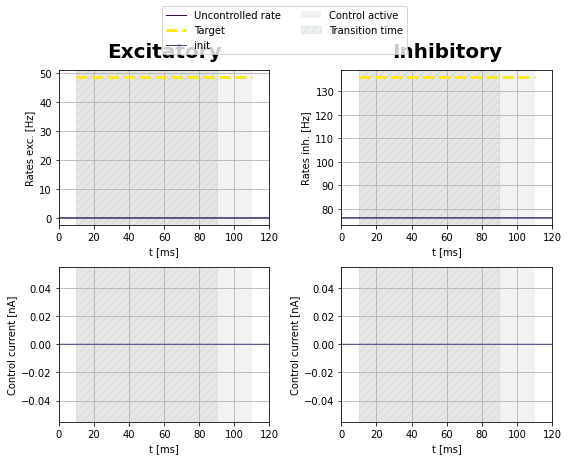

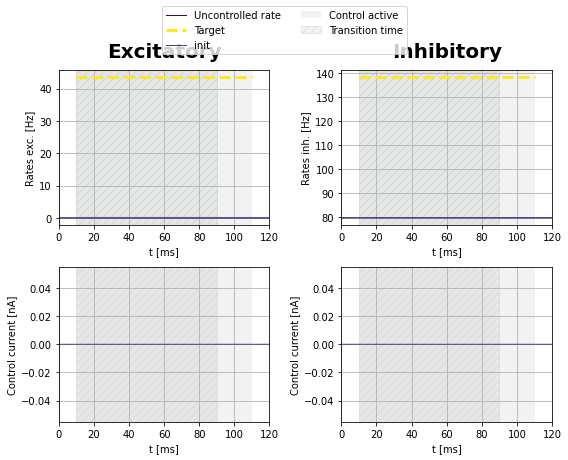

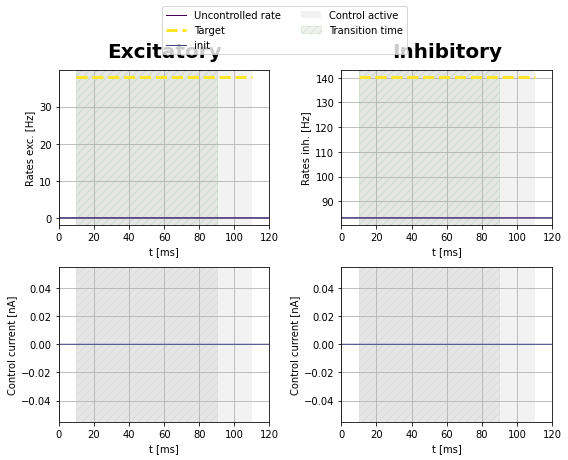

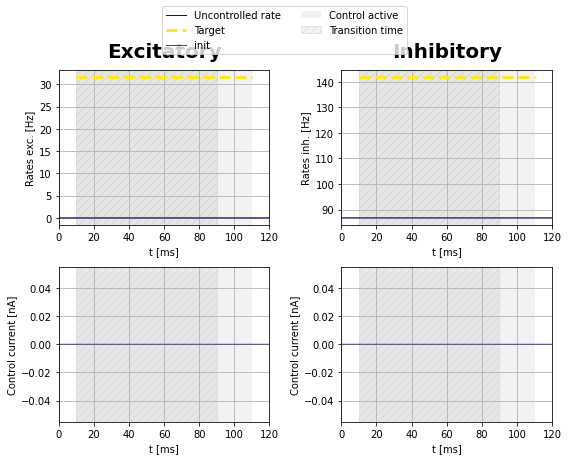

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  7 0.4500000000000001 0.40000000000000013
found solution for  7
-------  14 0.4250000000000001 0.4500000000000002
found solution for  14
-------  

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  52 , total integrated cost =  75.96665994592497
Improved over  52  iterations in  1.0852746106684208  seconds by  98.99341254036004  percent.
Problem in initial value trasfer:  Vmean_exc -56.63450958250894 -56.63450928620694
weight =  989.8004612012443
set cost params:  1.0 0.0 989.8004612012443
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7501.866899965307
Gradient descend method:  None
RUN  1 , total integrated cost =  7379.684834020255
RUN  2 , total integrated cost =  7379.66062425649
RUN  3 , total integrated cost =  7379.62390849603
RUN  4 , total integrated cost =  7379.039804575345
RUN  5 , total integrated cost =  7376.419534509783
RUN  6 , total integrated cost =  7376.180473424182
RUN  7 , total integrated cost =  7376.161443841832
RUN  8 , total integrated cost =  7376.151081197224
RUN  9 , total integrated cost =  7376.136894314499
RUN  10 , total integrated cost =  7376.057438579572
RUN  11 , total integrate

ERROR:root:Problem in initial value trasfer


RUN  19 , total integrated cost =  7359.567293512477
RUN  20 , total integrated cost =  7359.567293512475
Control only changes marginally.
RUN  21 , total integrated cost =  7359.567293512475
Improved over  21  iterations in  0.5010683052241802  seconds by  1.8968559206707738  percent.
Problem in initial value trasfer:  Vmean_exc -56.633102803368914 -56.63312001454402
-------  49 0.4500000000000001 0.6000000000000003
[0, 7, 14, 21, 28, 35] []
closest index  28
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11645.219536302864
Gradient descend method:  None
RUN  1 , total integrated cost =  11617.809668792523
RUN  2 , total integrated cost =  87.87968007806718
RUN  3 , total integrated cost =  78.2068066934292
RUN  4 , total integrated cost =  77.91761556169371
RUN  5 , total integrated cost =  77.70696970137064
RUN  6 , total integrated cost =  75.22844149687036
RUN  7 , total integrated cost =  75.18486713534

...

RUN  19 , total integrated cost =  13972.053209592696
RUN  20 , total integrated cost =  13972.053209592694
Control only changes marginally.
RUN  23 , total integrated cost =  13972.053209592685
Improved over  23  iterations in  0.512087183073163  seconds by  2.9101456006266204  percent.
Problem in initial value trasfer:  Vmean_exc -56.67650269585839 -56.67651041910525
-------  140 0.4500000000000001 0.9000000000000006
[0, 7, 14, 21, 28, 35, 98, 105] []
closest index  105
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  385.39938694259797
Gradient descend method:  None
RUN  1 , total integrated cost =  218.88553732285135
RUN  2 , total integrated cost =  216.14671721423804
RUN  3 , total integrated cost =  214.03053884419862
RUN  4 , total integrated cost =  211.0953641579068
RUN  5 , total integrated cost =  209.18035832973908
RUN  6 , total integrated cost =  206.83373781642265
RUN  7 , total integrated cost 

ERROR:root:Problem in initial value trasfer


RUN  50 , total integrated cost =  159.3719739802023
Control only changes marginally.
RUN  51 , total integrated cost =  159.3719739802023
Improved over  51  iterations in  1.1219603437930346  seconds by  58.647579788719426  percent.
Problem in initial value trasfer:  Vmean_exc -56.651665752572406 -56.651665220451314
weight =  628.7158443445636
set cost params:  1.0 0.0 628.7158443445636
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10005.861234409194
Gradient descend method:  None
RUN  1 , total integrated cost =  9852.501656400096
RUN  2 , total integrated cost =  9851.878337100505
RUN  3 , total integrated cost =  9851.862369103676
RUN  4 , total integrated cost =  9851.85882796685
RUN  5 , total integrated cost =  9851.858014834235
RUN  6 , total integrated cost =  9851.857637301293
RUN  7 , total integrated cost =  9851.857523648336
RUN  8 , total integrated cost =  9851.857479333301
RUN  9 , total integrated cost =  9851.857462969214
RUN  10 , total inte

ERROR:root:Problem in initial value trasfer


RUN  18 , total integrated cost =  9851.857458176319
RUN  19 , total integrated cost =  9851.857458176306
RUN  20 , total integrated cost =  9851.857458176297
Control only changes marginally.
RUN  22 , total integrated cost =  9851.857458176293
Improved over  22  iterations in  0.492080258205533  seconds by  1.5391356388523292  percent.
Problem in initial value trasfer:  Vmean_exc -56.65048712835309 -56.65050646023925
------------------------------------------------------------
-------------------- 1
------------------------------------------------------------
found solution:  [0, 7, 14, 21, 28, 35, 98, 105]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4500000000000001 0.40000000000000013
-------  14 0.4250000000000001 0.4500000000000002
-------  21 0.47500000000000014 0.4750000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  42 0.4250000000000001 0.5750000000000003
found solution fo

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  5187.489782399709
set cost params:  1.0 0.0 5187.489782399709
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5855.6162417789765
Gradient descend method:  None
RUN  1 , total integrated cost =  5853.626174270826
RUN  2 , total integrated cost =  5853.571818061239
RUN  3 , total integrated cost =  5853.563660208321
RUN  4 , total integrated cost =  5853.5615104375665
RUN  5 , total integrated cost =  5853.560870870588
RUN  6 , total integrated cost =  5853.560656564933
RUN  7 , total integrated cost =  5853.560557048819
RUN  8 , total integrated cost =  5853.5

ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  5853.560485563135
Control only changes marginally.
RUN  32 , total integrated cost =  5853.5604855631345
Improved over  32  iterations in  0.7118202913552523  seconds by  0.03510742731353389  percent.
Problem in initial value trasfer:  Vmean_exc -56.62602349904506 -56.62600093381703
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  12367.569488538316
set cost params:  1.0 0.0 12367.569488538316
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13545.724033266246
Gradient descend method:  None
RUN  1 , total integrated cost =  13545.33698726893
RUN  2 , total integrated cost =  13545.335663381577
RUN  3 , total integrated cost =  13545.335662872169


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  13545.335662872141
RUN  5 , total integrated cost =  13545.335662872134
RUN  6 , total integrated cost =  13545.335662872123
RUN  7 , total integrated cost =  13545.335662872123
Control only changes marginally.
RUN  7 , total integrated cost =  13545.335662872123
Improved over  7  iterations in  0.25243247114121914  seconds by  0.002867106942147757  percent.
Problem in initial value trasfer:  Vmean_exc -56.67384627826495 -56.673854394705295
-------  14 0.4250000000000001 0.4500000000000002
no convergence
weight =  2493.313571410588
set cost params:  1.0 0.0 2493.313571410588
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8784.656766712951
Gradient descend method:  None
RUN  1 , total integrated cost =  8784.567833492634
RUN  2 , total integrated cost =  8784.559416270653
RUN  3 , total integrated cost =  8784.557983819683
RUN  4 , total integrated cost =  8784.557626034053
RUN  5 , total integrated cost =  8784.557503708449
RUN

...

RUN  1 , total integrated cost =  14432.67299349676
Control only changes marginally.
RUN  1 , total integrated cost =  14432.67299349676
Improved over  1  iterations in  0.07202254049479961  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67649367158565 -56.676501610436674
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
[[False, False], [False, False], [True, False], [True, False], [False, False], [True, True], [False, False], [True, False], [True, False], [True, False], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, False], [True, True], [True, True], [False, False], [True, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  5232.11363241883
set cost params:  1.0 0.0 5232.11363241883
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.278226631926
Gradient descend method:  None
RUN  1 , total integrated cost =  5901.278226631917
RUN  2 ,

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  5901.27822663188
RUN  7 , total integrated cost =  5901.278226631877
RUN  8 , total integrated cost =  5901.278226631877
Control only changes marginally.
RUN  8 , total integrated cost =  5901.278226631877
Improved over  8  iterations in  0.27079750783741474  seconds by  8.384404281969182e-13  percent.
Problem in initial value trasfer:  Vmean_exc -56.62603844362573 -56.62601572299487
-------  7 0.4500000000000001 0.40000000000000013
converged for  7
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
converged for  21
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
-------  35 0.5500000000000003 0.5250000000000002
converged for  35
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.65

ERROR:root:Problem in initial value trasfer


140
[[False, False], [True, False], [True, True], [True, True], [True, False], [True, True], [True, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, False], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  5232.113948895466
set cost params:  1.0 0.0 5232.113948895466
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.278564925664
Gradient descend method:  None
RUN  1 , total integrated cost =  5901.278564925664
Control only changes marginally.
RUN  1 , total integrated cost =  5901.278564925664
Improved over  1  iterations in  0.07248697243630886  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62603844362573 -56.62601572299487
-------  7 0.4500000000000001 0.40000000000000013
converged for  7
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  319.16442475079856
Gradient descend method:  None
RUN  1 , total integrated cost =  13.46219001281922
RUN  2 , total integrated cost =  13.381872165020408
RUN  3 , total integrated cost =  13.373593531844227
RUN  4 , total integrated cost =  13.35425572089186
RUN  5 , total integrated cost =  13.33911222172979
RUN  6 , total integrated cost =  13.331291196861876
RUN  7 , total integrated cost =  13.327112438638004
RUN  8 , total integrated cost =  13.311939683688585
RUN  9 , total integrated cost =  13.301215418133204
RUN  10 , total integrated cost =  13.29847808955512
RUN  11 , total integrated cost =  13.292482502139103
RUN  12 , total integrated cost =  13.289347796240236
RUN  13 , total integrated cost =  13.271197782151278
RUN  14 , total integrated cost =  13.259935995823144
RUN  15 , total integrated cost =  13.247960078466189
R

ERROR:root:Problem in initial value trasfer


RUN  60 , total integrated cost =  13.117948845259276
Control only changes marginally.
RUN  62 , total integrated cost =  13.11794884525926
Improved over  62  iterations in  3.543221589177847  seconds by  95.8899088281842  percent.
Problem in initial value trasfer:  Vmean_exc -56.627619644491666 -56.62761962437814
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  130.7049663624899
Gradient descend method:  HS
RUN  1 , total integrated cost =  129.13760996949895
RUN  2 , total integrated cost =  128.1856603405568
RUN  3 , total integrated cost =  128.05518872160377
RUN  4 , total integrated cost =  128.04005455244086
RUN  5 , total integrated cost =  127.99187847956927
RUN  6 , total integrated cost =  127.99187847956921
RUN  7 , total integrated cost =  127.99037817797164
RUN  8 , total integrated cost =  127.10537722579662
RUN  9 , total integrated cost =  126.92332694455247
RUN  10 , total integrated cost =  126.8742

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  54 , total integrated cost =  114.94688570793588
Improved over  54  iterations in  4.002174040302634  seconds by  12.056221804802306  percent.
Problem in initial value trasfer:  Vmean_exc -56.627575451842574 -56.627575784214436
weight =  5133.898995206866
set cost params:  1.0 0.0 5133.898995206866
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5816.061744137391
Gradient descend method:  None
RUN  1 , total integrated cost =  5373.033290911196
RUN  2 , total integrated cost =  5365.151930223573
RUN  3 , total integrated cost =  5363.751475757443
RUN  4 , total integrated cost =  5357.038838486859
RUN  5 , total integrated cost =  5351.616202425803
RUN  6 , total integrated cost =  5351.201726319592
RUN  7 , total integrated cost =  5351.042947327661
RUN  8 , total integrated cost =  5351.02832515091
RUN  9 , total integrated cost =  5351.020414389015
RUN  10 , total integrated cost =  5351.017176434636
RUN  11 , total integ

...

RUN  1000 , total integrated cost =  155.93565029190304
RUN  1000 , total integrated cost =  155.93565029190304
Improved over  1000  iterations in  61.27206518128514  seconds by  32.48176835590451  percent.
Problem in initial value trasfer:  Vmean_exc -56.6516515757934 -56.6516514950808
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1558.923257769498
Gradient descend method:  HS
RUN  1 , total integrated cost =  1557.6665641750608
RUN  2 , total integrated cost =  1553.9299077748485
RUN  3 , total integrated cost =  1553.3543077243075
RUN  4 , total integrated cost =  1553.3017190903074
RUN  5 , total integrated cost =  1553.1325104350851
RUN  6 , total integrated cost =  1551.3064281268184
RUN  7 , total integrated cost =  1551.0035783126098
RUN  8 , total integrated cost =  1550.8274781343982
RUN  9 , total integrated cost =  1550.8209835547407
RUN  10 , total integrated cost =  1550.7224073173109
RUN  11 , total 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  22 , total integrated cost =  1547.7299300811442
Improved over  22  iterations in  1.7607877645641565  seconds by  0.7180165946314219  percent.
Problem in initial value trasfer:  Vmean_exc -56.651835021463775 -56.651825369817224
weight =  646.3977354729417
set cost params:  1.0 0.0 646.3977354729417
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9994.008747808666
Gradient descend method:  None
RUN  1 , total integrated cost =  9963.527071014068
RUN  2 , total integrated cost =  9958.35808241704
RUN  3 , total integrated cost =  9957.301712249962
RUN  4 , total integrated cost =  9957.290407436949
RUN  5 , total integrated cost =  9956.799654808508
RUN  6 , total integrated cost =  9956.303024063307
RUN  7 , total integrated cost =  9956.134500950093
RUN  8 , total integrated cost =  9956.132174671562
RUN  9 , total integrated cost =  9956.128096703032
RUN  10 , total integrated cost =  9955.817546310403
RUN  11 , total inte

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  32 , total integrated cost =  9954.033116825287
Improved over  32  iterations in  2.675190707668662  seconds by  0.3999959574994705  percent.
Problem in initial value trasfer:  Vmean_exc -56.65185727527059 -56.651848924858434


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


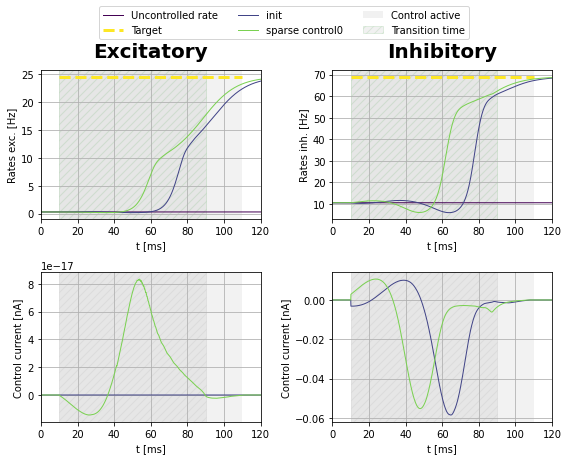

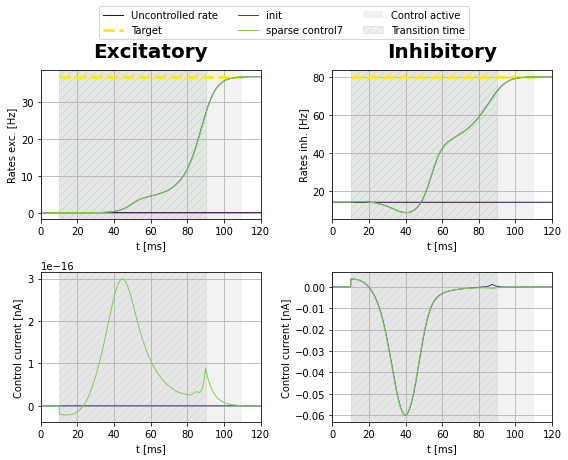

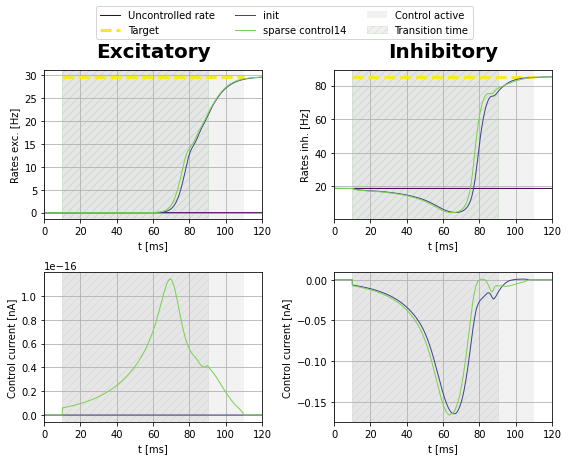

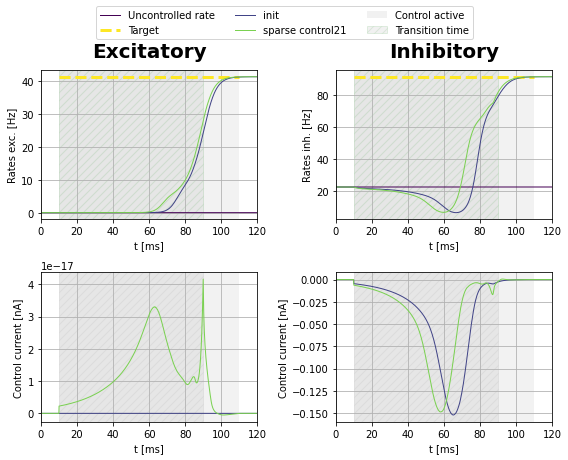

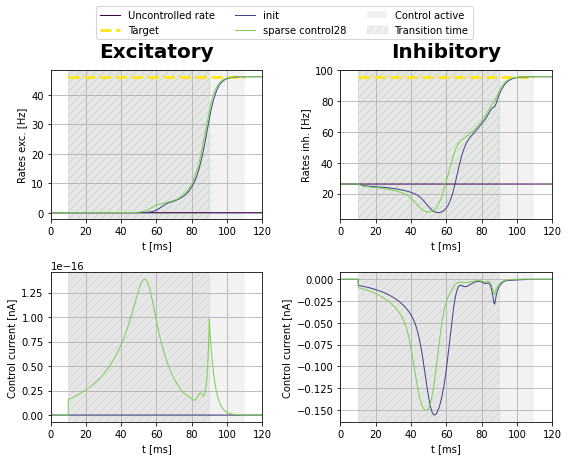

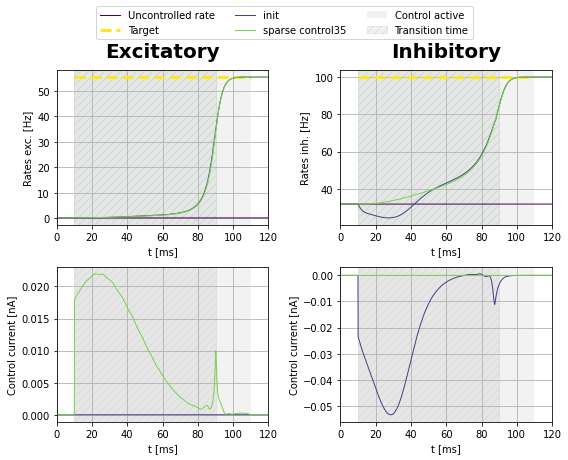

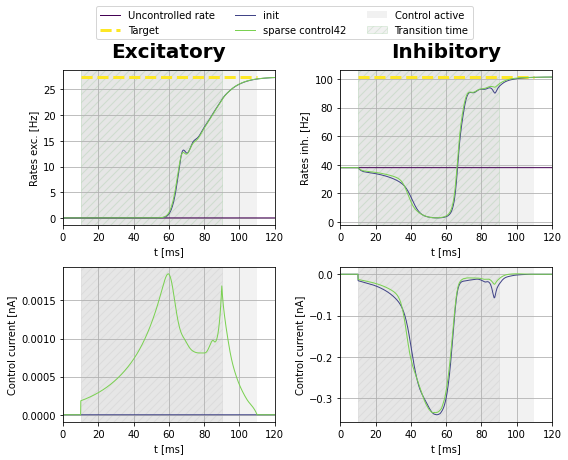

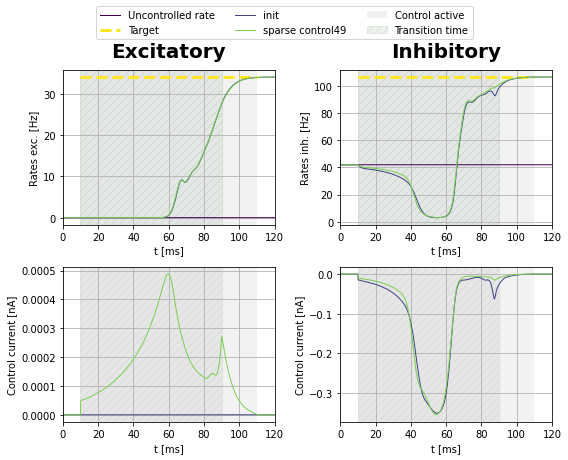

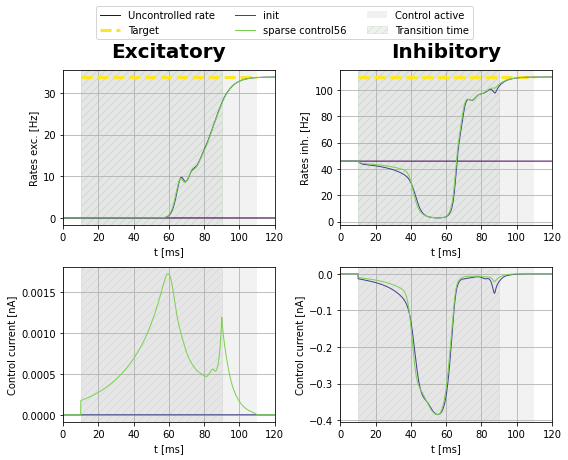

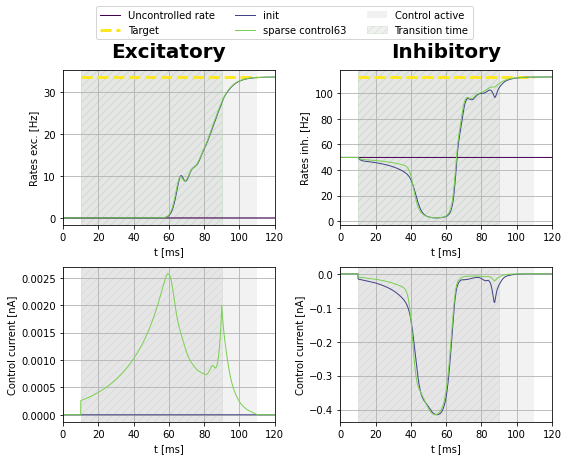

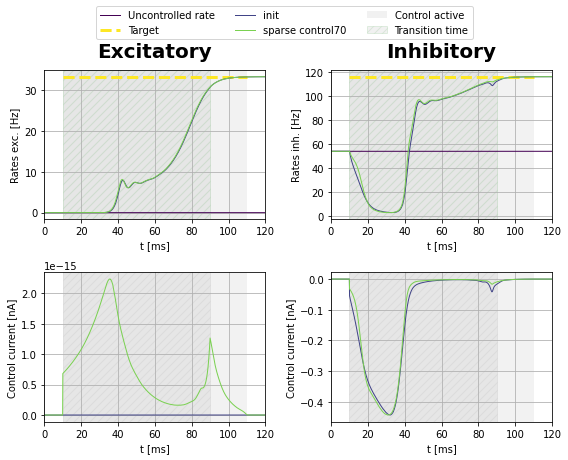

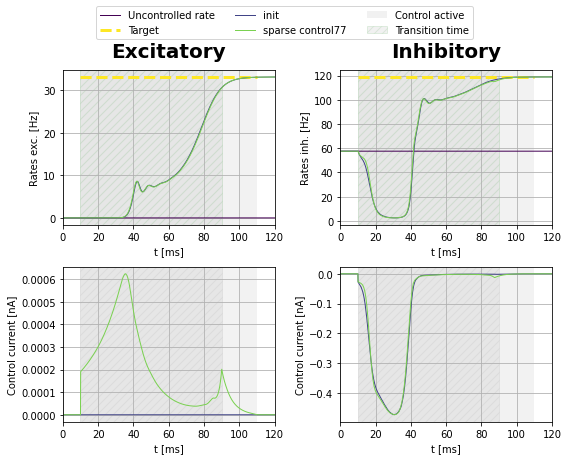

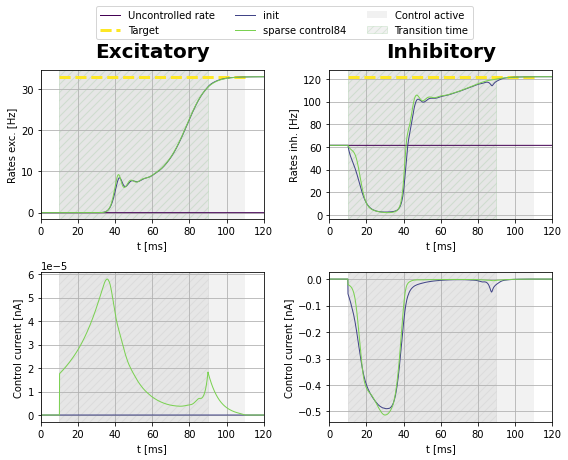

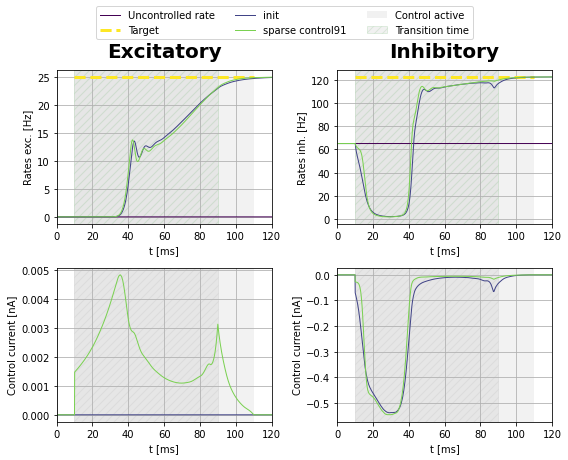

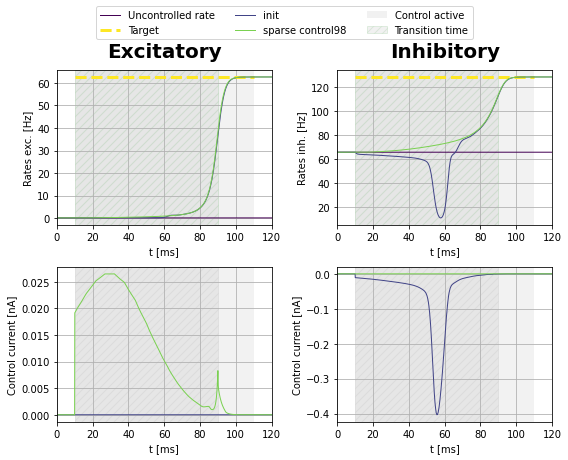

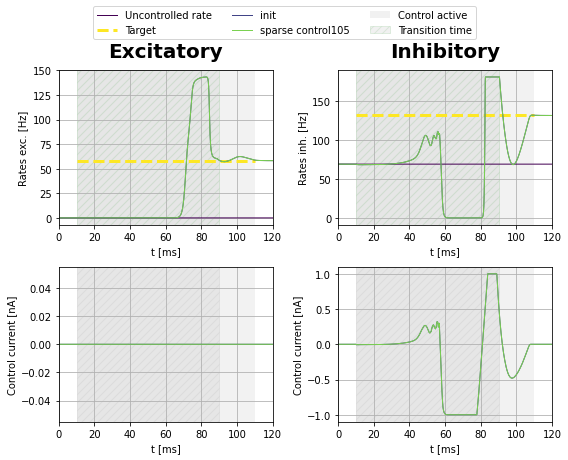

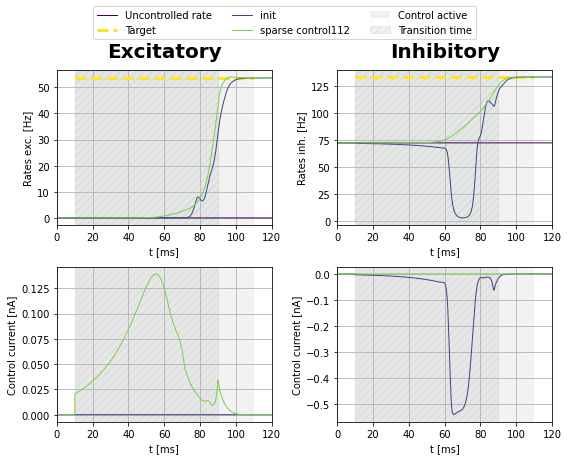

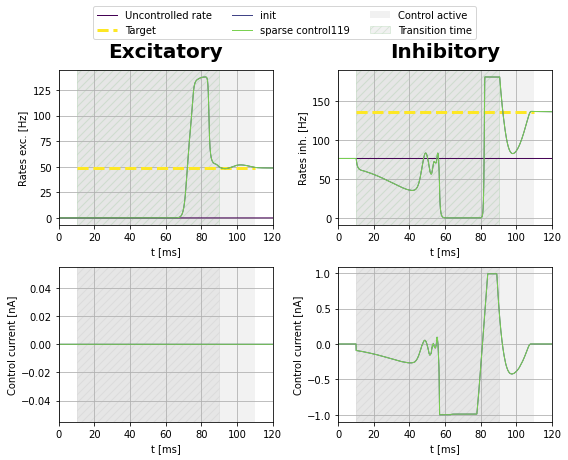

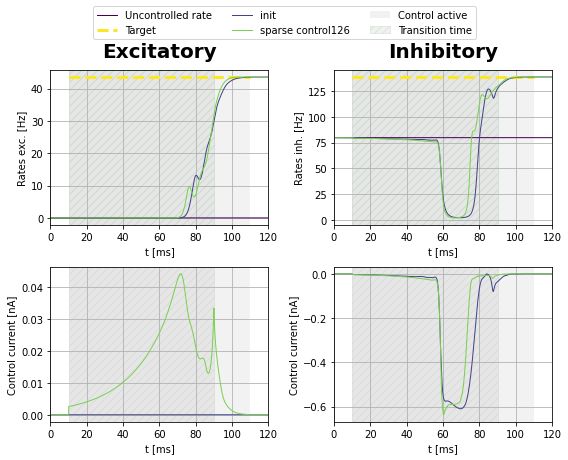

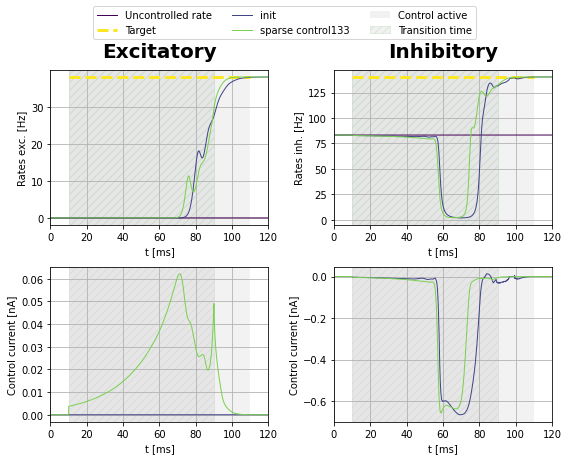

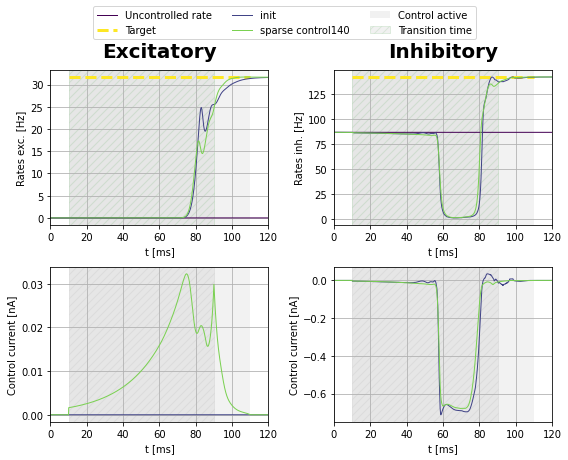

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  5661.920118645939
set cost params:  1.0 0.0 5661.920118645939
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5885.5166716997355
Gradient descend method:  None
RUN  1 , total integrated cost =  5885.342061130001
RUN  2 , total integrated cost =  5885.331490722422
RUN  3 , total integrated cost =  5885.330082332528
RUN  4 , total integrated cost =  5885.329834754565
RUN  5 , total integrated cost =  5885.329785675273
RUN  6 , total integrated cost =  5885.329773761776
RUN  7 , total integrated cost =  5885.329770846478
RUN  8 , total integrat

ERROR:root:Problem in initial value trasfer


RUN  18 , total integrated cost =  5885.329769869855
RUN  19 , total integrated cost =  5885.329769869855
Control only changes marginally.
RUN  19 , total integrated cost =  5885.329769869855
Improved over  19  iterations in  2.287653898820281  seconds by  0.0031756231492607867  percent.
Problem in initial value trasfer:  Vmean_exc -56.626009236991976 -56.626010812894656
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  12377.64590870184
set cost params:  1.0 0.0 12377.64590870184
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13548.564619950545
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  13548.564619950543
RUN  2 , total integrated cost =  13548.564619950543
Control only changes marginally.
RUN  2 , total integrated cost =  13548.564619950543
Improved over  2  iterations in  0.3916611522436142  seconds by  1.4210854715202004e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.673833004550104 -56.67384146358393
-------  14 0.4250000000000001 0.4500000000000002
no convergence
weight =  2515.824923001357
set cost params:  1.0 0.0 2515.824923001357
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8786.869848732398
Gradient descend method:  None
RUN  1 , total integrated cost =  8786.837731561096
RUN  2 , total integrated cost =  8786.837328260252
RUN  3 , total integrated cost =  8786.83731585144
RUN  4 , total integrated cost =  8786.837315216848
RUN  5 , total integrated cost =  8786.837315184586
RUN  6 , total integrated cost =  8786.837315184033
RUN  7 , total integrated cost =  8786.837315184022
RUN  

...

RUN  1 , total integrated cost =  5901.367092292144
Control only changes marginally.
RUN  1 , total integrated cost =  5901.367092292144
Improved over  1  iterations in  0.21830646321177483  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.626008884338454 -56.626010457526235
-------  7 0.4500000000000001 0.40000000000000013
converged for  7
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
converged for  21
-------  28 0.5000000000000002 0.5000000000000002
no convergence
weight =  7783.644626470181
set cost params:  1.0 0.0 7783.644626470181
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21310.35494435642
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  21310.35494435642
Control only changes marginally.
RUN  1 , total integrated cost =  21310.35494435642
Improved over  1  iterations in  0.19997373595833778  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.697829739264016 -56.69783062699963
-------  35 0.5500000000000003 0.5250000000000002
converged for  35
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
no convergence
weight =  1590.944368799018
set cost params:  1.0 0.0 1590.944368799018
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11610.154799251835
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  11610.154799251835
Control only changes marginally.
RUN  1 , total integrated cost =  11610.154799251835
Improved over  1  iterations in  0.21114922128617764  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.66178050109169 -56.661791009631706
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
converged for  70
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
-------  84 0.4500000000000001 0.7250000000000004
converged for  84
-------  91 0.4250000000000001 0.7500000000000004
converged for  91
-------  98 0.6000000000000003 0.7500000000000004
converged for  98
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  12

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  165.52212300573382
Gradient descend method:  None
RUN  1 , total integrated cost =  1.274819921950662
RUN  2 , total integrated cost =  1.2706898410089145
RUN  3 , total integrated cost =  1.2520134044373048
RUN  4 , total integrated cost =  1.24889631757725
RUN  5 , total integrated cost =  1.2445566492862612
RUN  6 , total integrated cost =  1.24297174866401
RUN  7 , total integrated cost =  1.2423386380105716
RUN  8 , total integrated cost =  1.2410258360833832
RUN  9 , total integrated cost =  1.2407694563421112
RUN  10 , total integrated cost =  1.2393944371979388
RUN  11 , total integrated cost =  1.2374828617019606
RUN  12 , total integrated cost =  1.237328998920082
RUN  13 , total integrated cost =  1.2369932711380653
RUN  14 , total integrated cost =  1.236044508212002
RUN  15 , total integrated cost =  1.2358770631022509
RUN  

ERROR:root:Problem in initial value trasfer


State only changes marginally.
Control only changes marginally.
RUN  42 , total integrated cost =  1.2251626210616524
Improved over  42  iterations in  0.9049106109887362  seconds by  99.2598194133728  percent.
Problem in initial value trasfer:  Vmean_exc -56.627620461228304 -56.627620445737435
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  137.0224418997191
Gradient descend method:  None
RUN  1 , total integrated cost =  1.2511186170824755
RUN  2 , total integrated cost =  1.2382507031930572
RUN  3 , total integrated cost =  1.2293493073316073
RUN  4 , total integrated cost =  1.2261115520958636
RUN  5 , total integrated cost =  1.2100867945006142
RUN  6 , total integrated cost =  1.2051680642396854
RUN  7 , total integrated cost =  1.2050787901331277
RUN  8 , total integrated cost =  1.2041757718463384
RUN  9 , total integrated cost =  1.2025730085207436
RUN  10 , total integrated

ERROR:root:Problem in initial value trasfer


RUN  60 , total integrated cost =  1.19501264434958
Control only changes marginally.
RUN  61 , total integrated cost =  1.19501264434958
Improved over  61  iterations in  1.315517134964466  seconds by  99.12787085985217  percent.
Problem in initial value trasfer:  Vmean_exc -56.67416791091874 -56.674167899471456
-------  14 0.4250000000000001 0.4500000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  145.80905668607892
Gradient descend method:  None
RUN  1 , total integrated cost =  3.8072160955167447
RUN  2 , total integrated cost =  3.796882547781193
RUN  3 , total integrated cost =  3.7559648375458936
RUN  4 , total integrated cost =  3.7431150262816946
RUN  5 , total integrated cost =  3.7426538252294885
RUN  6 , total integrated cost =  3.7406068315255308
RUN  7 , total integrated cost =  3.7399420735959854
RUN  8 , total integrated cost =  3.739617910829469
RUN  9 , total integrated cost =  3.7383347276030983
RUN  10 ,

...

Control only changes marginally.
RUN  154 , total integrated cost =  12.755806688754362
Improved over  154  iterations in  3.155168728902936  seconds by  89.32052408878442  percent.
Problem in initial value trasfer:  Vmean_exc -56.692544801017654 -56.69254393188473
-------  133 0.47500000000000014 0.8750000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  64.20885726658031
Gradient descend method:  None
RUN  1 , total integrated cost =  17.372881848796233
RUN  2 , total integrated cost =  17.361225932498357
RUN  3 , total integrated cost =  17.361065041879566
RUN  4 , total integrated cost =  17.36105263836423
RUN  5 , total integrated cost =  17.36105013150488
RUN  6 , total integrated cost =  17.361049531312304
RUN  7 , total integrated cost =  17.361049358089364
RUN  8 , total integrated cost =  17.361049304813196
RUN  9 , total integrated cost =  17.361049287194156
RUN  10 , total integrated cost =  17.36104928139136
RUN

ERROR:root:Problem in initial value trasfer


RUN  19 , total integrated cost =  17.361049278127133
RUN  20 , total integrated cost =  17.361049278126867
Control only changes marginally.
RUN  25 , total integrated cost =  17.36104927812673
Improved over  25  iterations in  0.5477371346205473  seconds by  72.96159748483348  percent.
Problem in initial value trasfer:  Vmean_exc -56.677033952604546 -56.6770286348791
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  54.26449164528183
Gradient descend method:  None
RUN  1 , total integrated cost =  20.626652838531434
RUN  2 , total integrated cost =  20.580746871271035
RUN  3 , total integrated cost =  20.58065839110424
RUN  4 , total integrated cost =  20.58064429674974
RUN  5 , total integrated cost =  20.5806413255594
RUN  6 , total integrated cost =  20.580640379670328
RUN  7 , total integrated cost =  20.580640083756897
RUN  8 , total integrated cost =  20.580639980542813
RUN  9 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  24 , total integrated cost =  20.580639921062517
Improved over  24  iterations in  0.5248152110725641  seconds by  62.073467755683005  percent.
Problem in initial value trasfer:  Vmean_exc -56.652589558980715 -56.65256851618986


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.2251626210616524
Gradient descend method:  None
RUN  1 , total integrated cost =  1.2251626210616524
Control only changes marginally.
RUN  1 , total integrated cost =  1.2251626210616524
Improved over  1  iterations in  0.06944318674504757  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.627620461228304 -56.627620445737435
-------  7 0.4500000000000001 0.40000000000000013
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True Tr

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  3.723653208198038
Control only changes marginally.
RUN  1 , total integrated cost =  3.723653208198038
Improved over  1  iterations in  0.0637921430170536  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64410843756317 -56.644108161853524
-------  21 0.47500000000000014 0.4750000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.961706998960312
Gradient descend method:  None
RUN  1 , total integrated cost =  2.961706998960312
Control only changes marginally.
RUN  1 , total integrated cost =  2.961706998960312
Improved over  1  iterations in  0.06229427643120289  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.687521250811415 -56.68752134827536
-------  28 0.5000000000000002 0.5000000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.8673314462666

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


...

RUN  1 , total integrated cost =  1.2572601492322237
Control only changes marginally.
RUN  1 , total integrated cost =  1.2572601492322237
Improved over  1  iterations in  0.062045373022556305  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.6997675473279 -56.69976762457967
-------  105 0.5750000000000002 0.7750000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7.111208263931495
Gradient descend method:  None
RUN  1 , total integrated cost =  7.111208263931495
Control only changes marginally.
RUN  1 , total integrated cost =  7.111208263931495
Improved over  1  iterations in  0.06280487217009068  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70334258954701 -56.703341803015924
-------  112 0.5500000000000003 0.8000000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7.0965920203

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  10.014505886588083
Control only changes marginally.
RUN  1 , total integrated cost =  10.014505886588083
Improved over  1  iterations in  0.062252068892121315  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70096261505501 -56.700962644223736
-------  126 0.5000000000000002 0.8500000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  12.755806688754362
Gradient descend method:  None
RUN  1 , total integrated cost =  12.755806688754362
Control only changes marginally.
RUN  1 , total integrated cost =  12.755806688754362
Improved over  1  iterations in  0.06300124526023865  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.692544801017654 -56.69254393188473
-------  133 0.47500000000000014 0.8750000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17.361

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  20.580639921062517
Control only changes marginally.
RUN  1 , total integrated cost =  20.580639921062517
Improved over  1  iterations in  0.06692917458713055  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.652589558980715 -56.65256851618986
--------------- 21
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  7 0.4500000000000001 0.40000000000000013
converged for  7
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
converged for  21
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
---

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
